# Practical Session: MOFA Data Integration

This Jupyter notebook will guide you through the MOFA data integration practical of the course. You'll explore how to use Multi-Omics Factor Analysis (MOFA) to analyze a dataset of Chronic Lymphocytic Leukemia patients. All practical exercises will take place within this notebook, ensuring you have everything you need in one place.

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import mofaflex as mfl
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import decoupler as dc

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Prerequisites / Useful Resources

Before getting started, ensure you're familiar with some key Python packages used in this project. The links below provide helpful introductions.

### NumPy
A library for numerical computing, providing the np.array class for vector and matrix operations. In this project, numerical data (e.g., mRNA counts) will typically be stored as NumPy arrays.

[NumPy Quickstart](https://numpy.org/doc/stable/user/quickstart.html)

### Pandas
A powerful library for working with tabular data, offering the pd.DataFrame class. Unlike NumPy arrays, DataFrames allow labeled columns and rows, support multiple data types (e.g., integers and strings), and enable easy indexing by name.

[10 minutes to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)

### Matplotlib
The most widely used plotting library in Python. While mastering it takes time, this guide covers the essentials.

[Matplotlib Quick Start Guide](https://matplotlib.org/stable/users/explain/quick_start.html)

### AnnData

If you've worked with R, you probably know the SingleCellExperiment or SummarizedExperiment classes. AnnData is pretty much the same, but in Python.

<img src="graphics/anndata_schema.svg" alt="drawing" width="400"/>

An AnnData object has several key attributes:
- .X: The main data matrix, typically a count matrix with dimensions (n_observations × n_variables).
- .obs: A DataFrame containing metadata for each observation (row in .X), such as cell type or donor ID. Its index column can be accessed directly via .obs_names.
- .var: A DataFrame containing metadata for each variable (column in .X), such as a gene’s genomic location. Its index column can be accessed via .var_names.
- .obsm: A dictionary storing multi-dimensional observation data. Unlike .obs, which holds one-dimensional metadata (e.g., cell types), .obsm can store structured data like 2D UMAP coordinates or PCA components.
- .varm: The equivalent of .obsm for storing additional metadata related to variables.
- .layers: A dictionary for storing multiple versions of the data matrix (same shape as .X). This is useful for preserving raw counts while working with transformed versions (e.g., log-transformed data).
- .uns: A dictionary for miscellaneous information that doesn’t fit into observations or variables, such as dataset metadata or author contact details.
- .obsp & .varp: Rarely used; not covered in this guide.

Browse [AnnData Getting Started](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html) to learn more!

## Data Loading

First, we need to load the data. In this case, everything is already prepared as we need it - a dictionary of AnnData objects, one for each modality. Feel free to examine the `modality_dict` object and the contained modalities.

In [2]:
from data_loader import load_cll
modality_dict = load_cll()
metadata_df = pd.read_csv("data/metadata.txt", sep="\t").set_index("sample")

/Users/fwalter/embl_course_mofa_26/data_loader.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/Users/fwalter/embl_course_mofa_26/data_loader.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/Users/fwalter/embl_course_mofa_26/data_loader.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [3]:
metadata_df

,Gender,age,TTT,TTD,treatedAfter,died,IGHV,trisomy12
sample,,,,,,,,
H005,m,75.265753,0.574949,2.625599,True,False,1.0,0.0
H006,m,NaN,NaN,NaN,NaN,NaN,NaN,NaN
H007,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN
H008,m,NaN,NaN,NaN,NaN,NaN,NaN,NaN
H010,f,72.780822,2.932238,2.932238,False,False,0.0,0.0
...,...,...,...,...,...,...,...,...
H266,m,74.315068,0.002738,0.903491,True,False,1.0,NaN
H268,m,82.539726,0.076660,0.577687,True,False,NaN,0.0
H270,f,66.947945,0.216290,0.903491,True,False,1.0,0.0


In [4]:
modality_dict

{'mrna': AnnData object with n_obs × n_vars = 136 × 5000,
 'mutations': AnnData object with n_obs × n_vars = 200 × 69,
 'methylation': AnnData object with n_obs × n_vars = 200 × 4248,
 'drugs': AnnData object with n_obs × n_vars = 200 × 310}

## Training a MOFA-FLEX Model

Now that the data is prepared, we are ready to train the MOFA model. This step is straightforward thanks to the structured data format we have set up. While the original mofapy2 package can be used for this, a more convenient option is the new mofa-flex package.
In the next steps, we will train the MOFA model using mofa-flex and explore its results.

One last step for out data setup needs to be done though: Currently, we have a dictionary of AnnData objects where the keys denote the modality names and the values are the corresponding AnnData objects. MOFA-FLEX expects a nested dictionary though, where the first level keys represent the sample groups and the second level keys represent the modalities. In our case, we only have one sample group and therefore just call it "group_1".

WARNING	Device cuda:0 is not available. Using default device: cpu


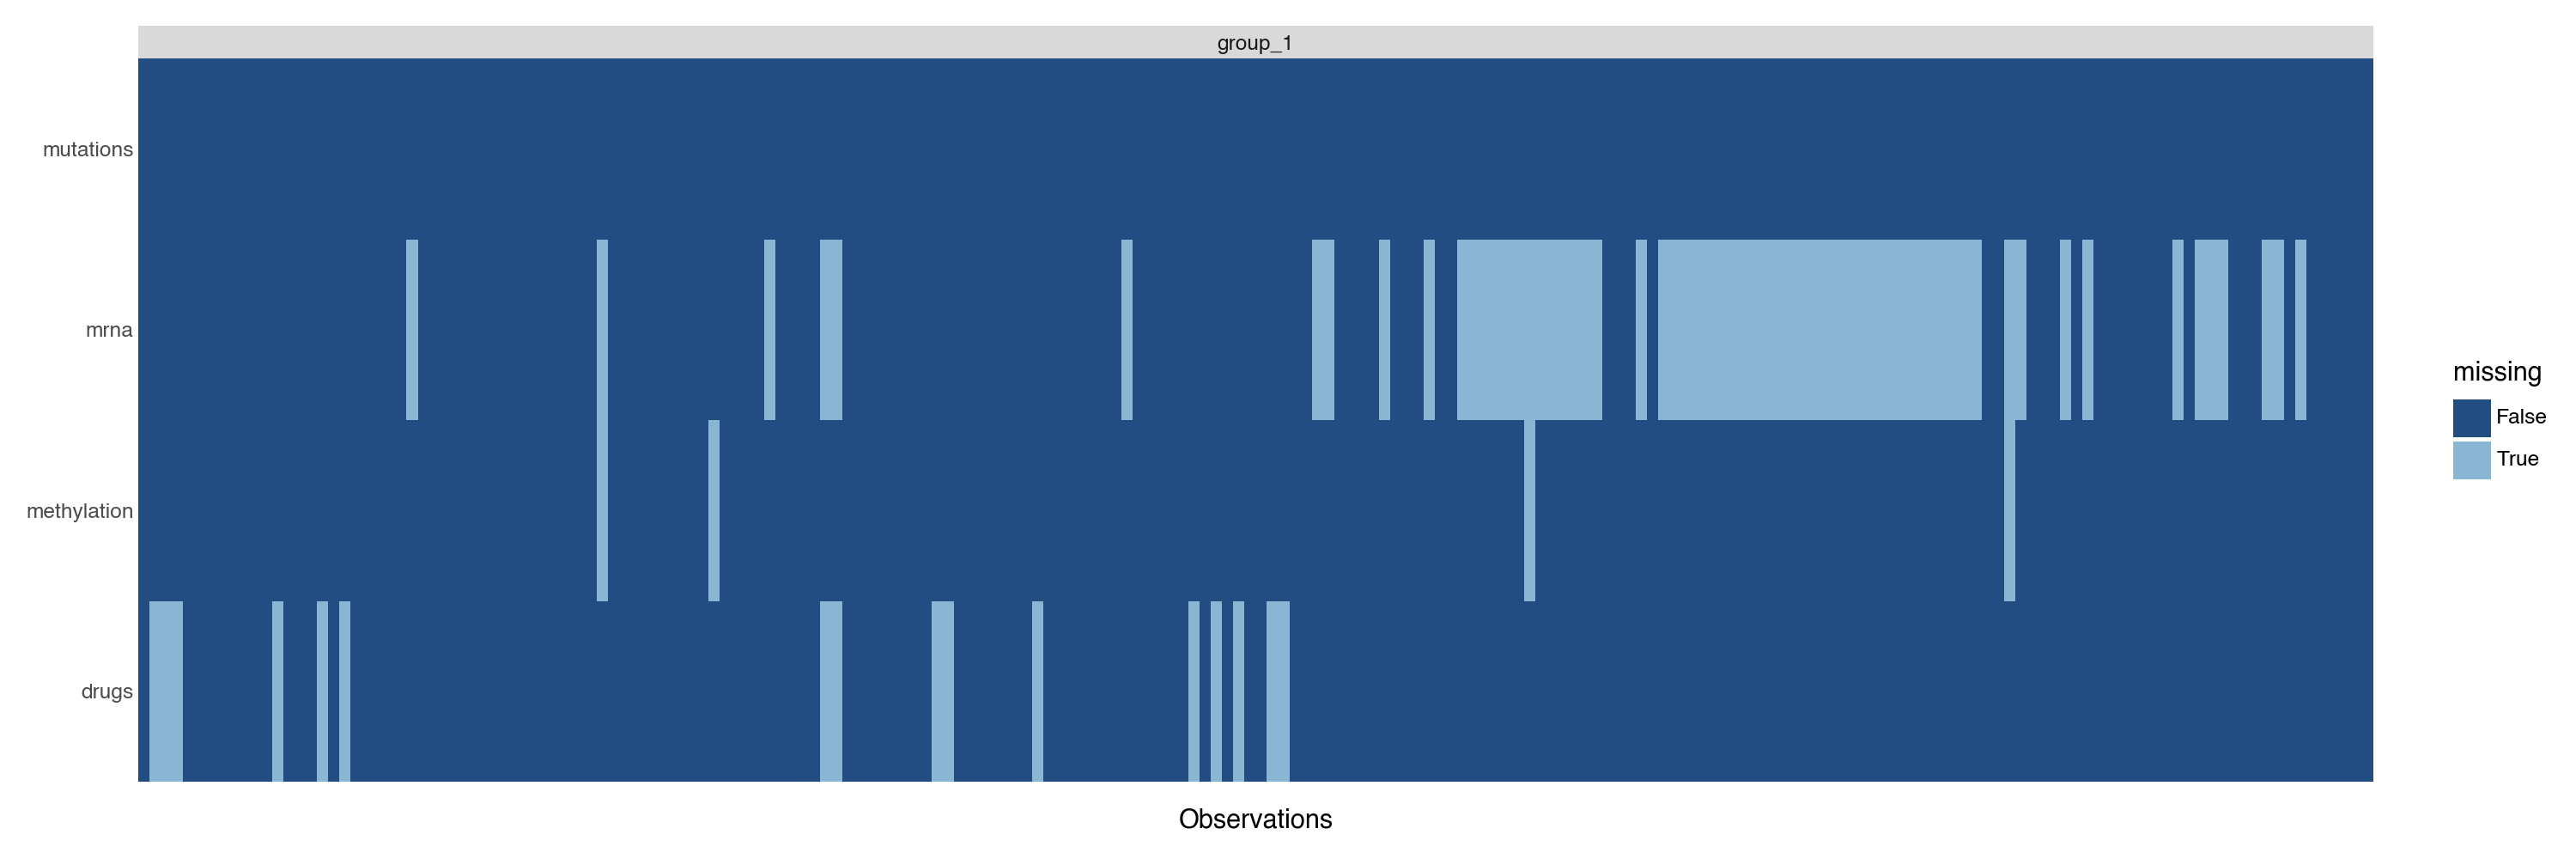

WARNING	Could not import dask. Data arrays may be copied, resulting in high memory usage.
/opt/homebrew/envs/ebi_sysbio_25/lib/python3.11/site-packages/mofaflex/_core/utils.py:108: RuntimeWarning: Mean of empty slice
INFO	Initializing factors using `random` method...


  0%|          | 0/10000 [00:00<?, ?epochs/s]

INFO	Training converged after 4402 epochs.
INFO	Saving results to models/mofaflex...
WARNING	models/mofaflex already exists, overwriting


In [5]:
# MOFA-FLEX expects a nested dictionary, with sample group at the first level and modality at the second level.
data = {"group_1": modality_dict}

model = mfl.MOFAFLEX(
    data,
    mfl.DataOptions(
        plot_data_overview=True,
    ),
    mfl.ModelOptions(
        n_factors=10,
        weight_prior="Horseshoe",
        factor_prior="Normal",
        likelihoods="Normal",
    ),
    mfl.TrainingOptions(
        device="cuda:0",
        max_epochs=10000,
        lr=0.05,
        early_stopper_patience=1000,
        save_path=f"models/mofaflex",
        seed=1234,
    )
)

#### Exercise

Make sure you understand all the input parameters of MOFA-FLEX. If you're not sure, it's a good idea to look them up in the [documentation](https://mofaflex.readthedocs.io/stable/).

### Inspection of the trained model

We'll now have a look at the result of our model training.

One useful property of a trained MOFA model is its ability to quantify the explained variance (R²) for each factor in every modality. This helps assess the importance of different factors across modalities.

If a factor explains little to no variance in any modality, it is likely not very informative and can be deprioritized in further analysis. Instead, focus on factors that contribute significantly to one or more modalities, as these are more likely to capture meaningful biological variation.

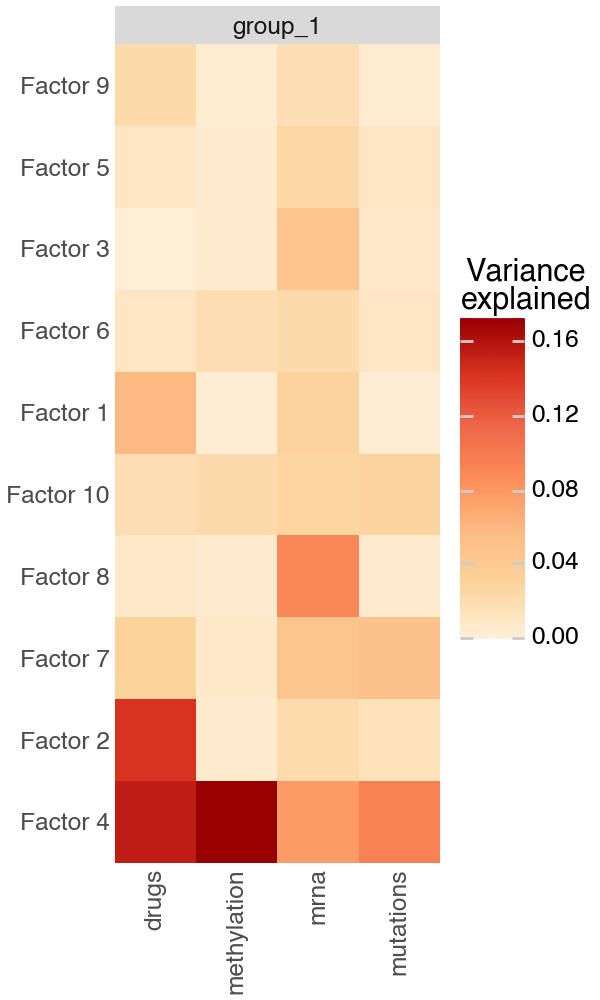

In [6]:
mfl.pl.variance_explained(model)

Examining the correlation of factor scores is also important. If two or more factors are highly correlated, they may be capturing the same underlying variation. In such cases, it might be reasonable to focus on just one of them to simplify the analysis without losing meaningful information.

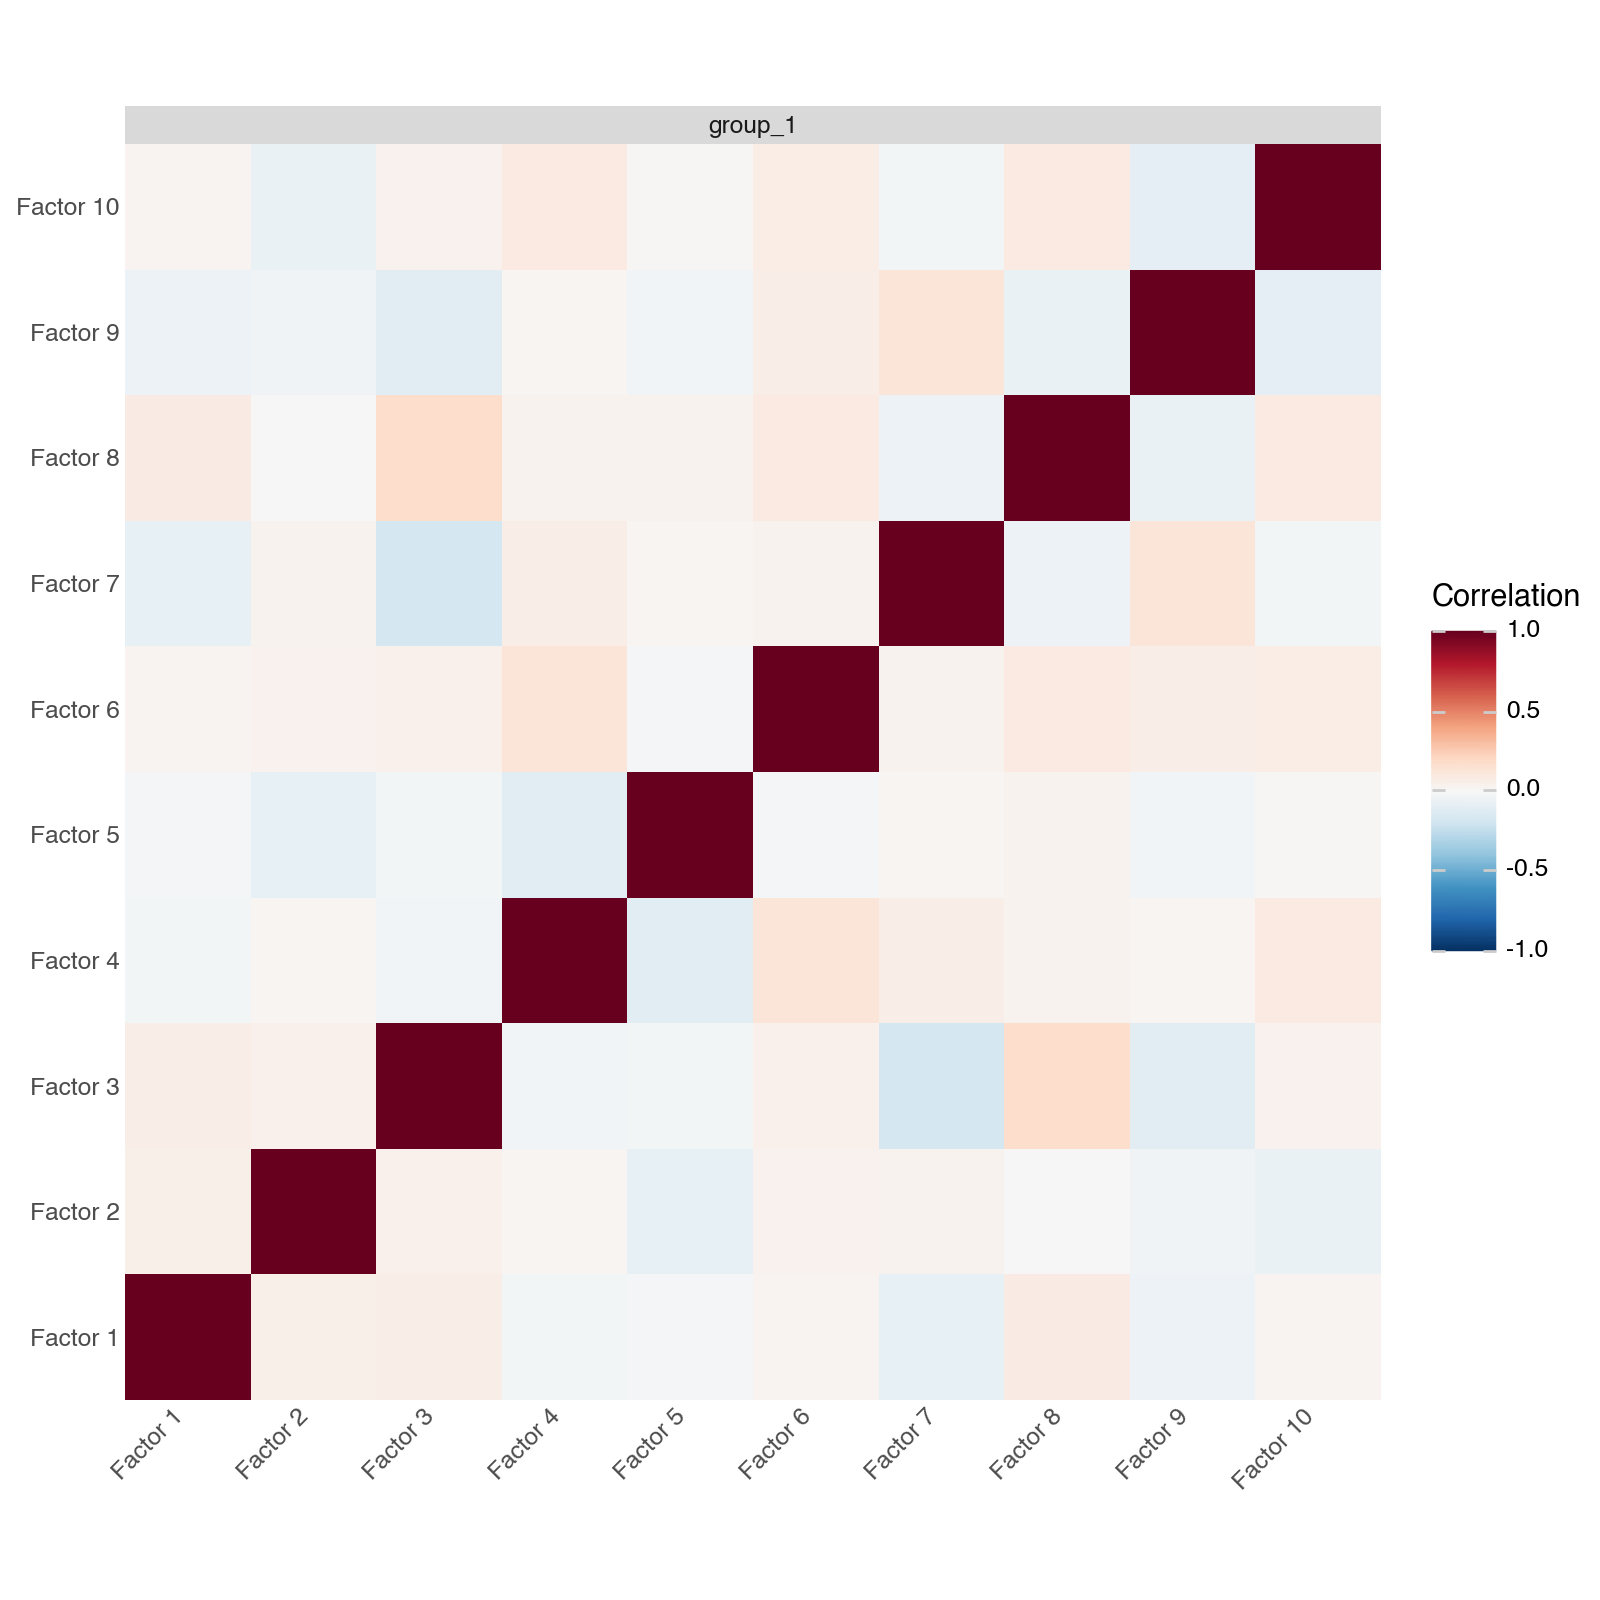

In [7]:
mfl.pl.factor_correlation(model)

#### Exercise

1. Train a second MOFA model with a different number of factors. Make sure to save it under a different name. Load the new model using mofax and re-plot the explained variance and factor score correlations. Do you observe similar patterns compared to the first model?
2. Compare total explained variance: How does the total explained variance change between the two models? Is the difference in variance explained consistent with what you expected?
3. Choosing the right number of factors:
   - Why is selecting too many factors problematic?
   - Why can too few factors limit the model’s usefulness?
   - What is the trade-off between interpretability and capturing meaningful variation?

Understanding these points will help optimize MOFA for meaningful biological insights.

WARNING	Device cuda:0 is not available. Using default device: cpu


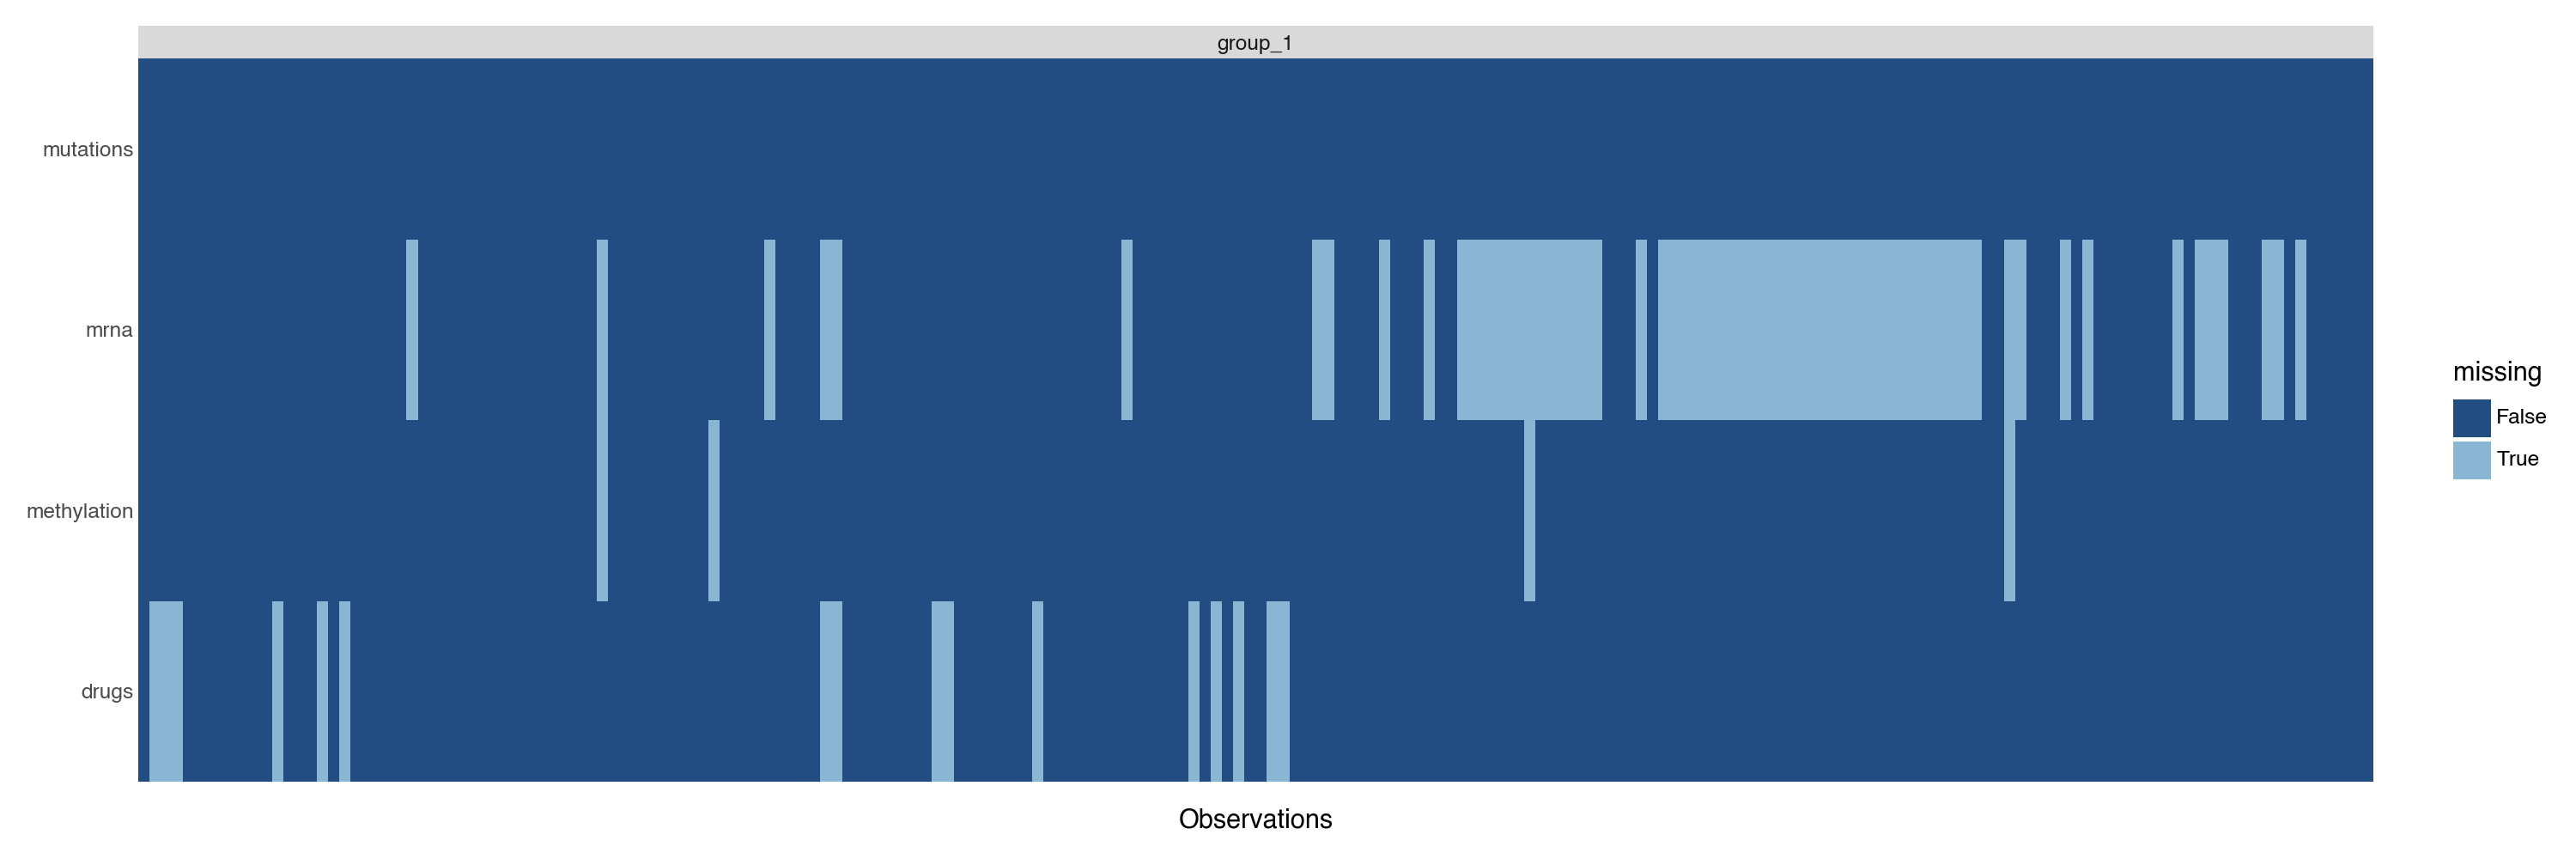

/opt/homebrew/envs/ebi_sysbio_25/lib/python3.11/site-packages/mofaflex/_core/utils.py:108: RuntimeWarning: Mean of empty slice
INFO	Initializing factors using `random` method...


  0%|          | 0/10000 [00:00<?, ?epochs/s]

INFO	Training converged after 2840 epochs.
INFO	Saving results to models/mofaflex_2...
WARNING	models/mofaflex_2 already exists, overwriting


In [8]:
# Exercise 1
model_2 = mfl.MOFAFLEX(
    data,
    mfl.DataOptions(
        plot_data_overview=True,
    ),
    mfl.ModelOptions(
        n_factors=5,
        weight_prior="Horseshoe",
        factor_prior="Normal",
        likelihoods="Normal",
    ),
    mfl.TrainingOptions(
        device="cuda:0",
        max_epochs=10000,
        lr=0.05,
        early_stopper_patience=1000,
        save_path=f"models/mofaflex_2",
        seed=1234,
    )
)

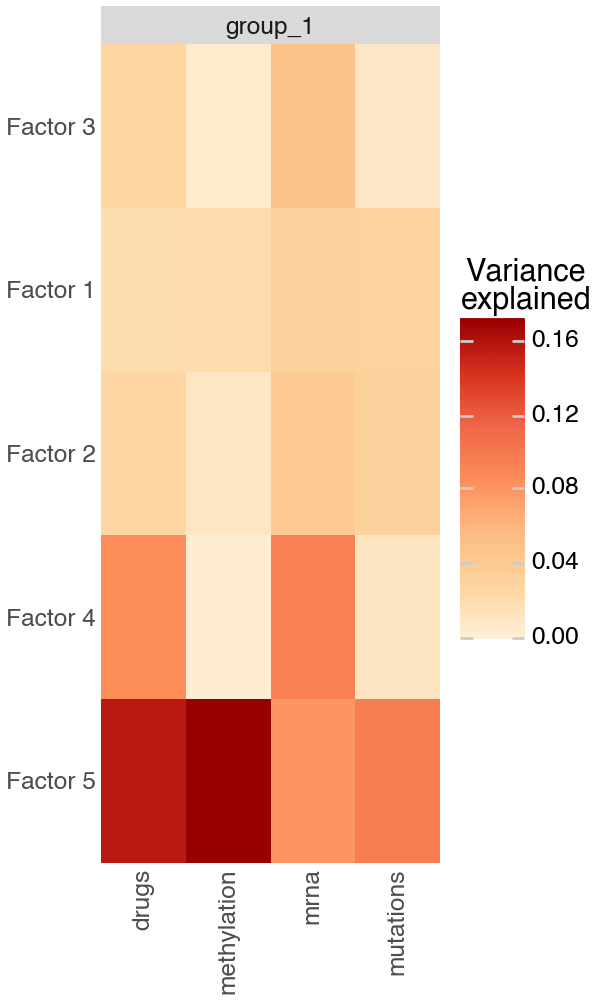

In [9]:
mfl.pl.variance_explained(model_2)

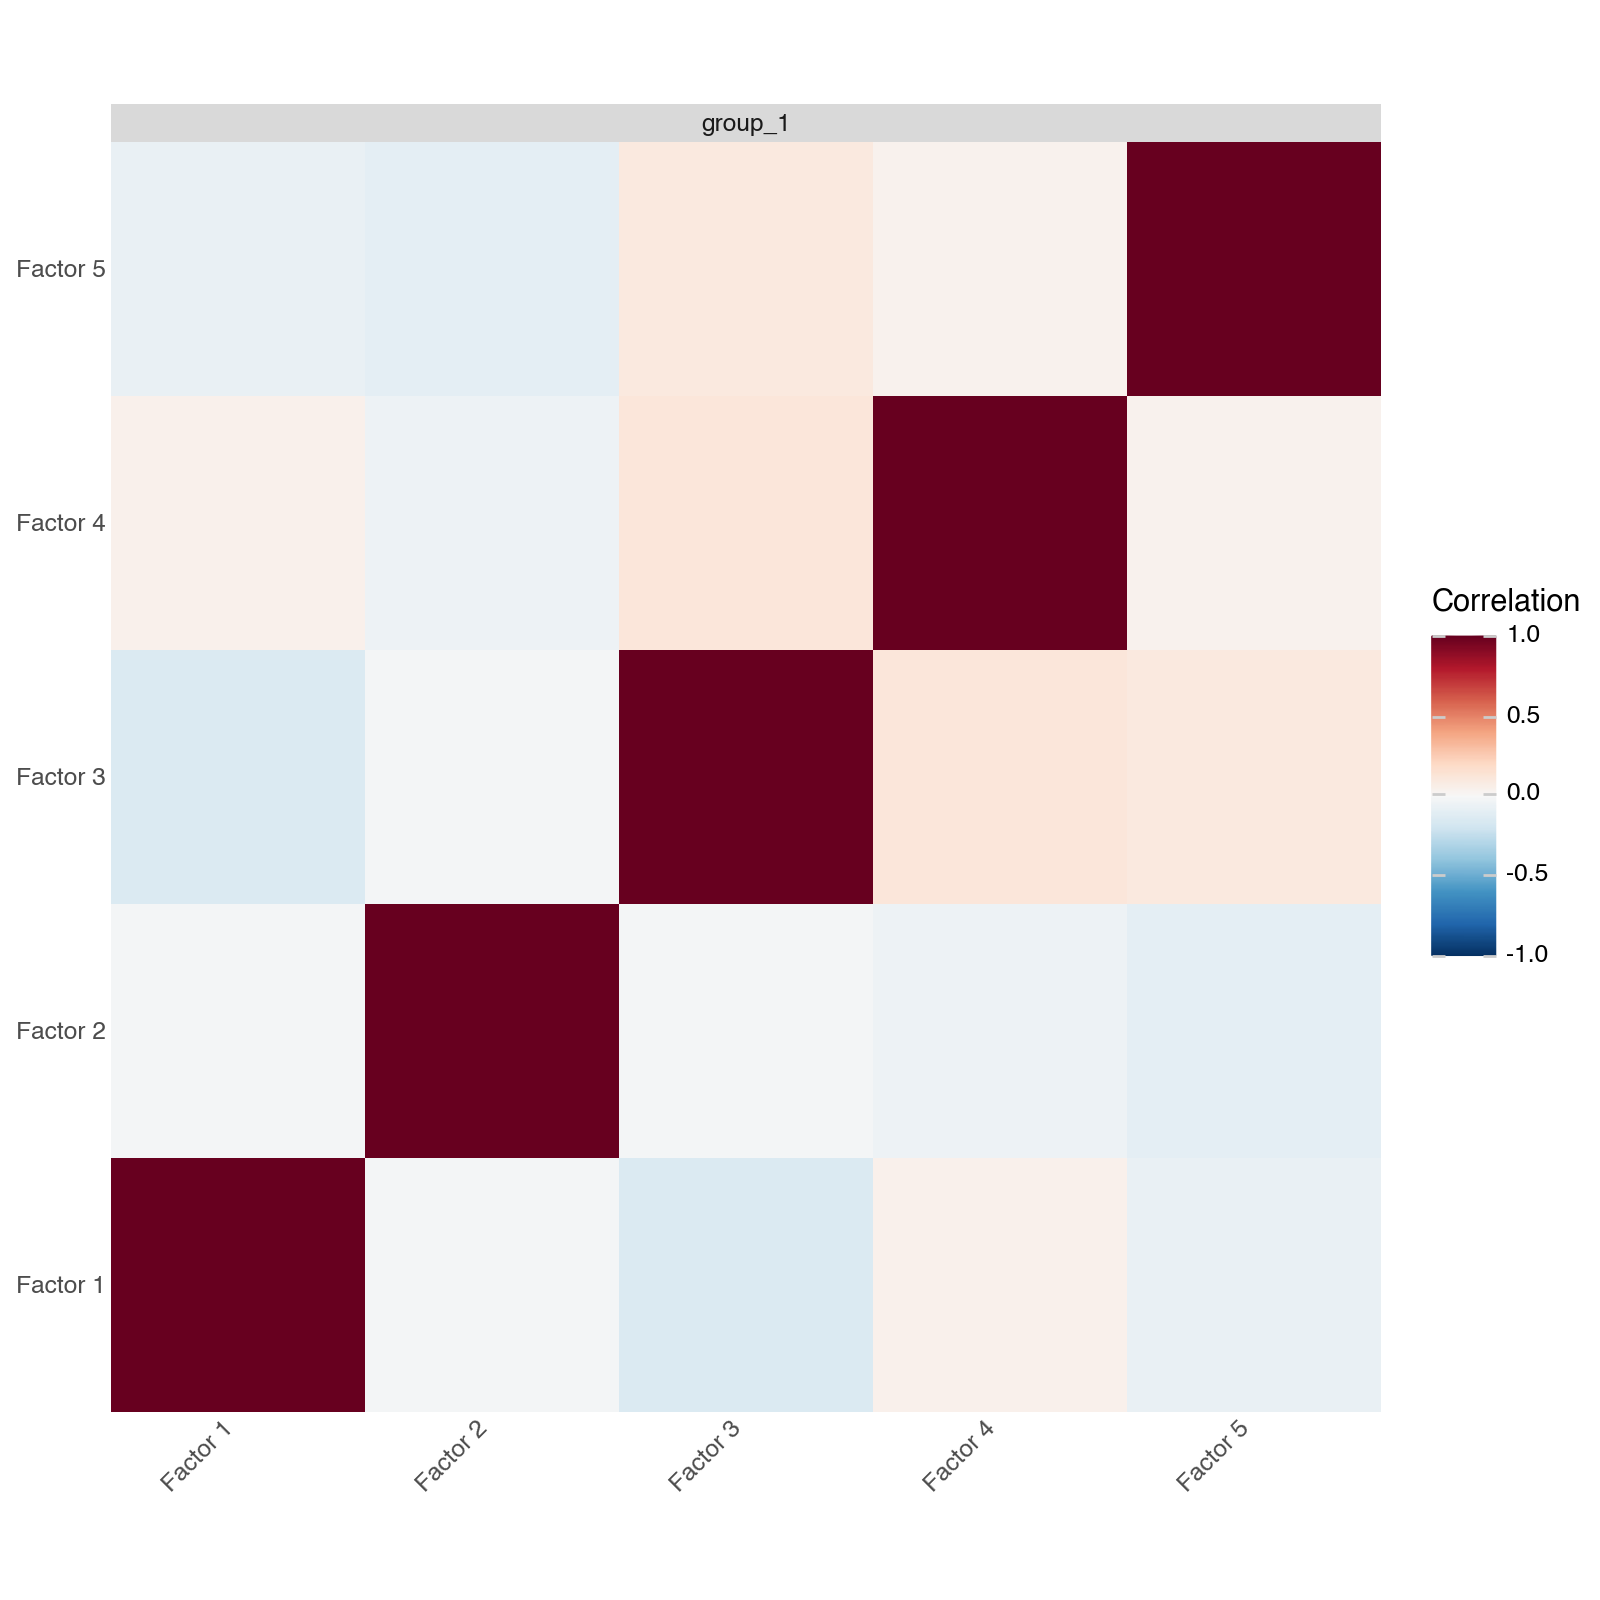

In [10]:
mfl.pl.factor_correlation(model_2)

In [11]:
# Exercise 2
print("Model with 10 factors:")
print(model.get_r2()["group_1"].sum(axis=0))
print("Model with 5 factors:")
print(model_2.get_r2()["group_1"].sum(axis=0))

Model with 10 factors:
mrna           0.405394
mutations      0.229588
methylation    0.251001
drugs          0.457643
dtype: float32
Model with 5 factors:
mrna           0.298723
mutations      0.179496
methylation    0.211362
drugs          0.317710
dtype: float32


## Downstream Analysis Part I - Understanding the Factor Scores

The factor scores matrix has dimensions (n_samples × n_factors), meaning that for each sample, we have a set of inferred factor values. These scores capture patterns and variation in the multi-omics data.

You can extract the factor scores as a NumPy array, giving you full flexibility for custom analysis and visualization. However, both mofax and muon provide built-in plotting functions to simplify the process.

In the next steps, we will explore how to analyze and interpret these factor scores effectively.

In [12]:
factor_scores = model.get_factors()["group_1"]

factor_scores

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
H045,0.000436,-0.067483,-0.021628,0.212889,-0.115205,0.035624,0.004427,-0.145174,-0.022104,0.061645
H109,0.038541,-0.040787,-0.115460,0.189551,0.059632,-0.014568,-0.185599,-0.043278,-0.016414,0.039684
H024,0.055728,-0.067990,0.173987,-0.219094,0.000040,-0.108220,0.063308,0.084565,0.020959,0.009454
H056,0.055147,-0.077478,0.110957,-0.171353,-0.018587,-0.082670,0.041137,0.089777,-0.057668,-0.053204
H079,-0.206337,-0.010538,-0.030055,0.169767,0.013248,-0.007670,0.068651,-0.127269,-0.008035,0.019051
...,...,...,...,...,...,...,...,...,...,...
H175,-0.012580,-0.066932,-0.028308,0.198373,0.036267,-0.037658,0.063823,-0.293097,-0.055215,0.033167
H179,-0.154747,-0.034076,-0.066241,-0.159797,-0.145755,-0.116143,-0.014057,-0.287602,-0.012851,0.005029
H050,0.087931,-0.038755,-0.214254,-0.301042,0.008838,-0.039691,-0.023693,0.275377,-0.021500,0.068831
H180,-0.046341,-0.023933,-0.062395,0.169019,0.096088,0.045069,0.054919,-0.365819,0.068332,0.036837


We can visualize the factor scores using a heatmap:

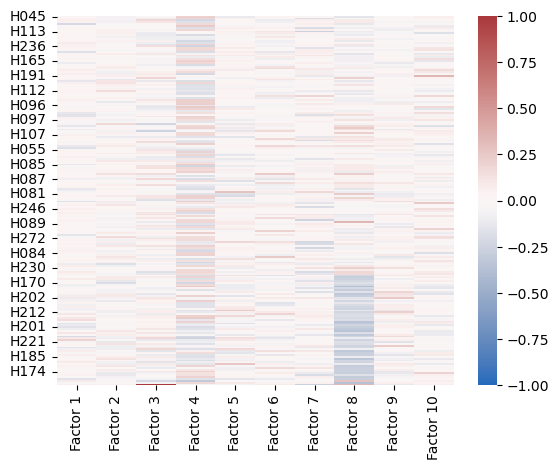

In [13]:
sns.heatmap(factor_scores, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.show()

We can visualize the relationship between two individual factors by using the plot_factors_scatter function.

This scatter plot helps identify potential correlations or patterns between factors. If the points form a clear trend (e.g., linear or clustered patterns), it suggests a relationship between the selected factors. If no structure is visible, the factors may capture independent sources of variation.

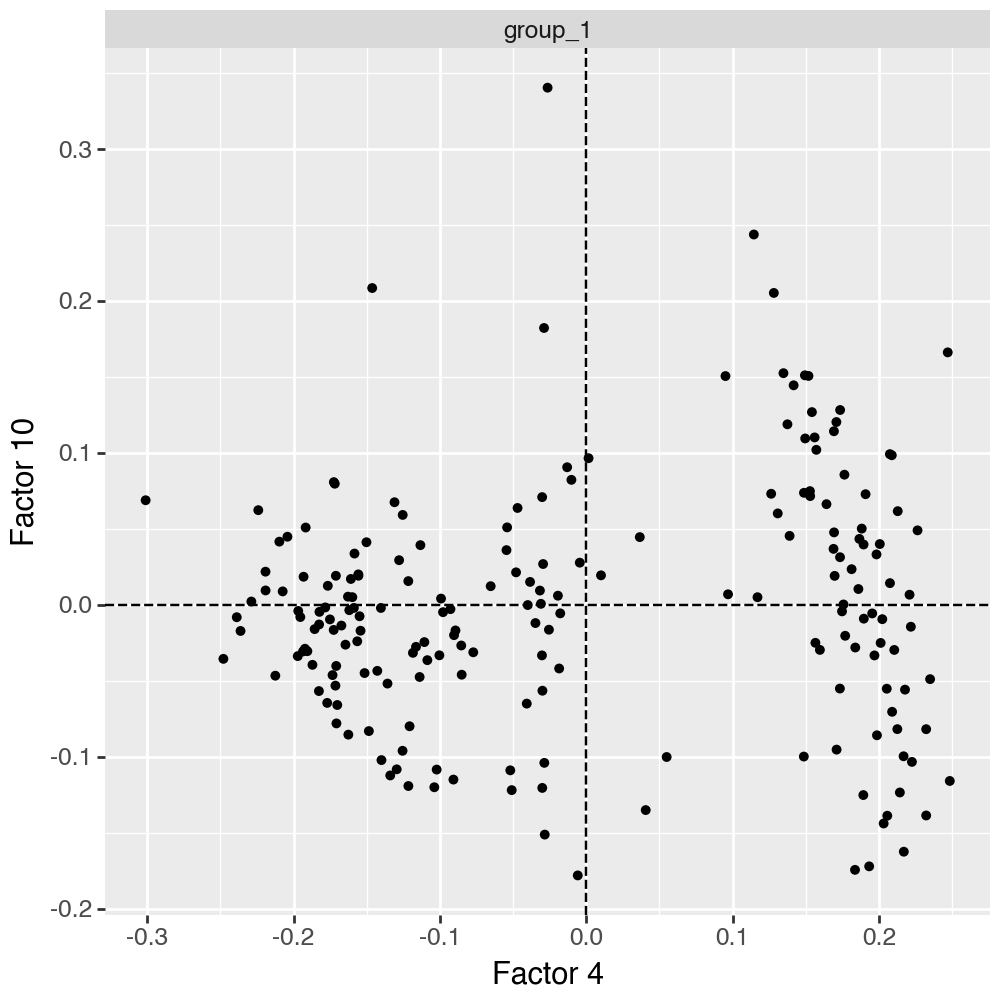

In [14]:
mfl.pl.factors_scatter(model, x="Factor 4", y="Factor 10")

#### Exercise
1. Identify two uncorrelated factors using the factor correlation plot from earlier.
2. Create a scatter plot of their factor scores using the factors_scatter function. Does the distribution confirm that they are uncorrelated?

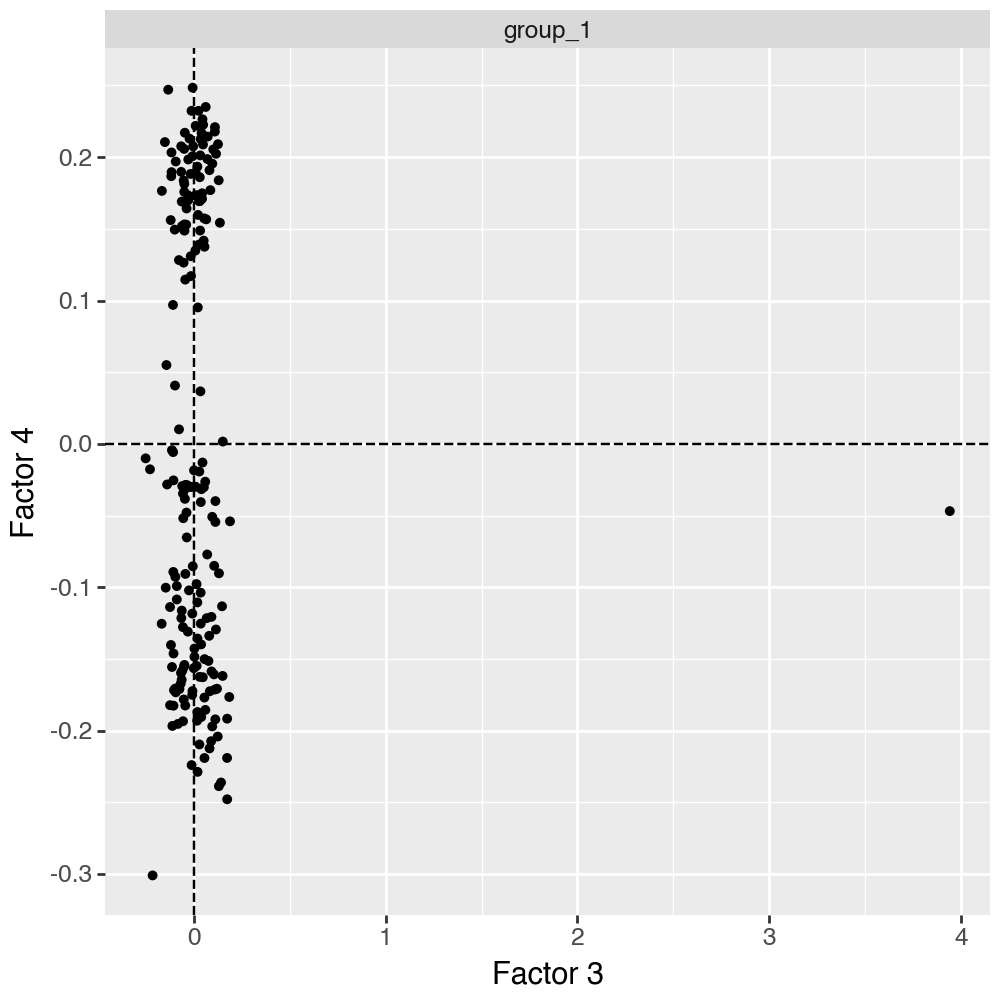

In [15]:
# Exercise 2
mfl.pl.factors_scatter(model, x="Factor 3", y="Factor 4")

Some factors may naturally separate samples into distinct groups. These factors are often particularly interesting, because they tell us something about the biological differences between those samples. It’s useful to check whether these groups correspond to known metadata by coloring the dots in the scatter plot accordingly.

As you can see in the next code cell, one of the factors distinguishes patients based on IGHV mutation status.

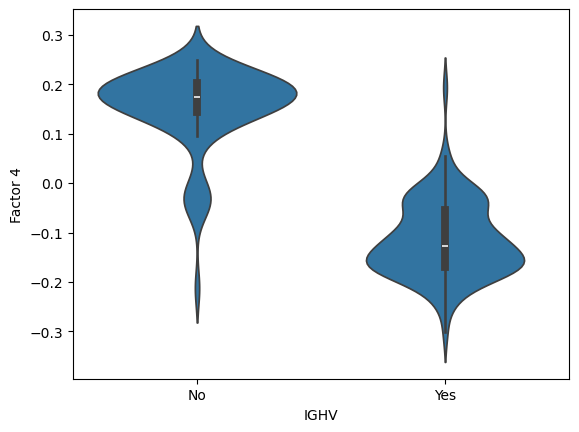

In [16]:
factor_scores["IGHV"] = metadata_df.loc[factor_scores.index]["IGHV"].map({-1: "Unknown", 0: "No", 1: "Yes"})
sns.violinplot(data=factor_scores, x="IGHV", y="Factor 4")
plt.show()

#### Exercise
1. Make violin plots to find a factor that distinguishes patients by their trisomy 12 status.
2. Make a scatter plot with a factor on one axis that separates patients by IGHV status and a factor on another axis that separates them by trisomy 12 status. Color the plot by IGHV / trisomy 12 status.
3. How many groups of patients seem to be present in the data set according to these factors?

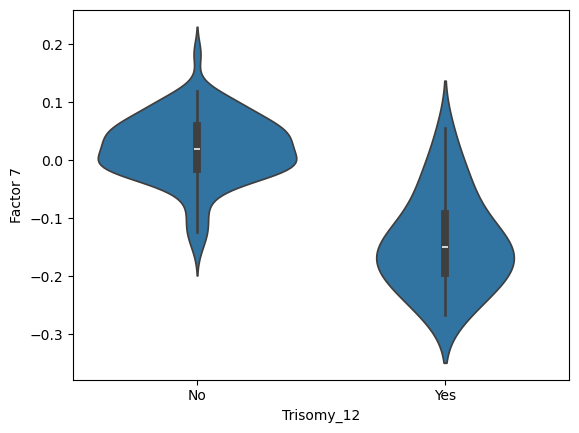

In [17]:
# Exercise 1
factor_scores["Trisomy_12"] = modality_dict["mutations"].to_df()["m_trisomy12"].map({-1: "Unknown", 0: "No", 1: "Yes"})
sns.violinplot(data=factor_scores, x="Trisomy_12", y="Factor 7")
plt.show()

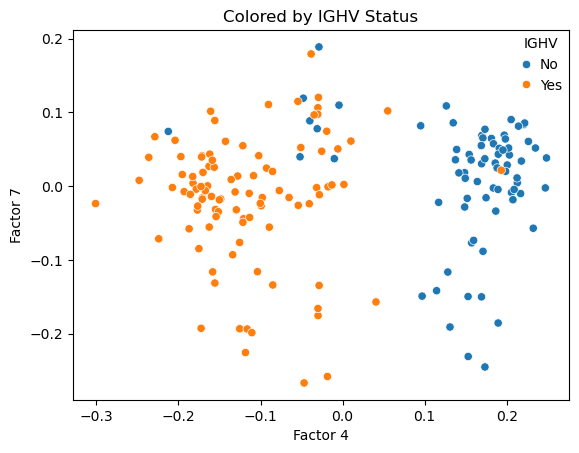

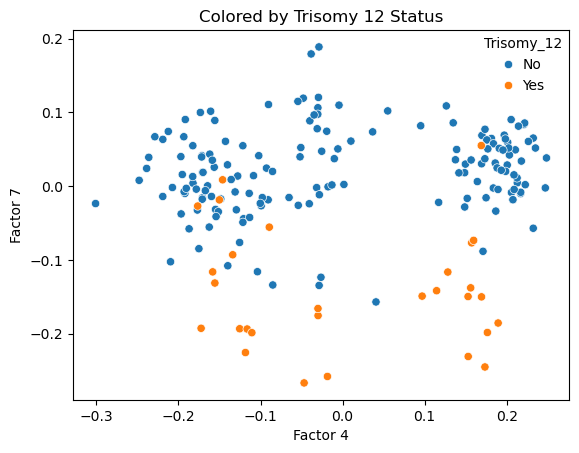

In [18]:
# Exercise 2
sns.scatterplot(factor_scores, x="Factor 4", y="Factor 7", hue=factor_scores["IGHV"])
plt.title("Colored by IGHV Status")
plt.show()

sns.scatterplot(factor_scores, x="Factor 4", y="Factor 7", hue=factor_scores["Trisomy_12"])
plt.title("Colored by Trisomy 12 Status")
plt.show()

## Downstream Analysis Part II - Understanding the factor loadings
So far, we've observed that:

- One factor is important across all modalities and likely captures general variation between patients.
- The same factor helps separate patients with and without IGHV mutation.
- Another factor helps distinguish patients with and without trisomy 12.

Now, let’s dive deeper into these factors by examining their factor loadings in the different modalities.

Factor loadings (or weights) describe how strongly each variable in a modality contributes to a factor. By analyzing these loadings, we can link specific variables to the factors and understand their biological relevance.

In [19]:
factor_loadings_mrna = model.get_weights()["mrna"]
factor_loadings_drugs = model.get_weights()["drugs"]
factor_loadings_methylation = model.get_weights()["methylation"]
factor_loadings_mutations = model.get_weights()["mutations"]

These factor loadings can be visualised with heatmaps as well:

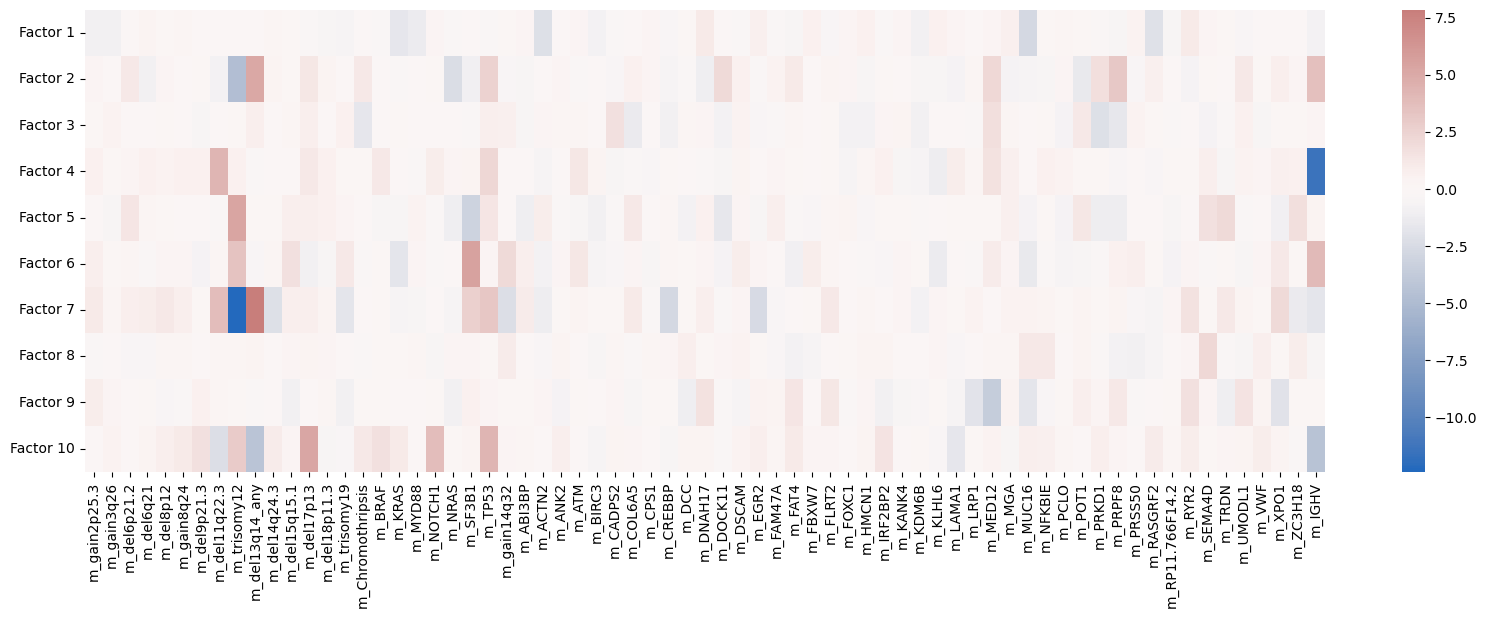

In [20]:
plt.figure(figsize=(20, 6))
sns.heatmap(factor_loadings_mutations, cmap="vlag", center=0)
plt.xticks(ticks=[i+0.5 for i in range(factor_loadings_mutations.shape[1])], labels=factor_loadings_mutations.columns, rotation=90)
plt.show()

Or, alternatively as a scatter plot:

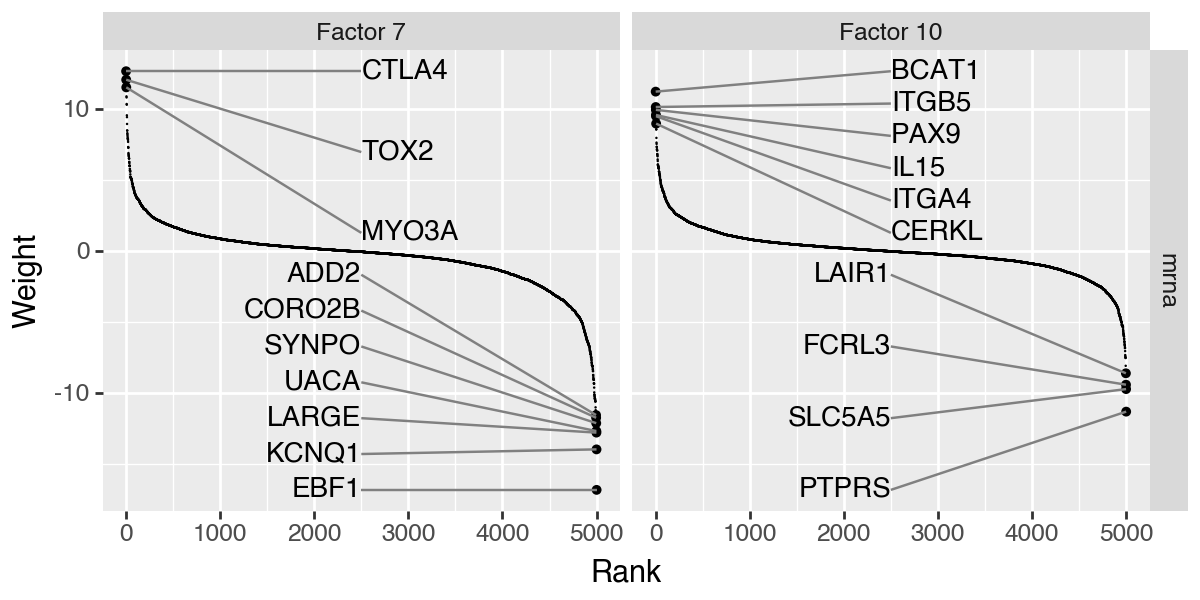

In [21]:
mfl.pl.weights(
    model,
    views=["mrna"],
    factors=["Factor 10", "Factor 7"]
)

#### Exercise

1. Check the factor loadings for the previously identified important factors in the mutations modality. What do you expect regarding the IGHV and trisomy 12 variables?
2. The formula for the factorisation is $$y_{nd} = \sum_d w_{dk} z_{nk},$$ where $y_{nd}$ is the data value of observation $n$ and variable $d$, $w_{dk}$ is the factor loading of variable $d$ and factor $k$, and $z_{nk}$ is the factor score of sample $n$ and factor $k$. If a variable has a high positive value in a sample, and the corresponding factor score is also positive, what does this imply for the sign of the factor loading? Validate your assumption by looking at the factor that separates samples by their IGHV status (remember how we encoded the IGHV mutation numerically).
3. We've seen that one factor has high values for patients with IGHV mutation. Have a look at the factor loadings for the same factor in other modalities (like transcriptome or drug response) now. What does it mean for a variable to have a high positive or negative loading? Can you create hypotheses about potential drug targets or drug efficacy?

In [22]:
# Exercise 1
print(factor_loadings_mutations.loc["Factor 4"].sort_values(ascending=False))
print(factor_loadings_mutations.loc["Factor 7"].sort_values(ascending=False))

m_del11q22.3     4.353985
m_TP53           2.259021
m_MED12          1.546885
m_ATM            1.315624
m_del17p13       1.270292
                  ...    
m_FOXC1         -0.615551
m_KDM6B         -0.636334
m_ACTN2         -0.675582
m_KLHL6         -1.182003
m_IGHV         -11.386089
Name: Factor 4, Length: 69, dtype: float32
m_del13q14_any     7.844631
m_del11q22.3       3.754983
m_TP53             3.245324
m_SF3B1            2.637852
m_XPO1             2.005712
                    ...    
m_del14q24.3      -2.180592
m_gain14q32       -2.272547
m_EGR2            -2.568715
m_CREBBP          -2.769300
m_trisomy12      -12.395836
Name: Factor 7, Length: 69, dtype: float32


Finally, let us try to link the individual factors to some known biological processes. This can be done using gene set enrichment analysis, a technique that takes as input a number of genes and searches a data base to identify biological processes (or anything else, depends on the data base) that involve roughly this set of genes. To do this, we use the absolute values of the factor loadings (or weights), because the larger the absolute value the more important the gene is. We use the [decoupler package](https://decoupler.readthedocs.io/en/latest/).

In [23]:
# load the data base
net = dc.op.hallmark()

# run gene set enrichment analysis
es, pvals = dc.mt.gsea(data=factor_loadings_mrna.abs(), net=net)

In [24]:
es

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Factor 1,1.017017,1.171234,0.788109,0.863675,0.831170,1.064096,1.344390,1.024979,1.165392,0.958057,...,0.877428,1.103677,0.954459,1.102024,1.546050,1.499320,1.121831,1.377708,1.277360,1.146471
Factor 2,0.990528,1.541870,1.063112,1.290318,1.199904,1.156424,1.170405,0.814169,1.090037,1.065549,...,1.149984,1.063065,1.013965,0.971091,0.959044,0.736955,1.107281,0.670740,1.054414,1.021539
Factor 3,0.866431,1.014209,1.240077,1.101743,1.093088,0.818055,1.324227,0.899138,1.375911,1.042257,...,1.129456,-0.723507,0.991460,1.430104,1.368342,1.425405,1.107841,1.408581,1.120635,1.084194
Factor 4,1.304921,0.854676,1.106201,1.521758,1.042656,1.112303,1.172940,1.014367,1.026644,0.738485,...,0.940293,0.939427,1.022672,0.758694,0.760844,0.662375,1.111102,0.841499,1.376907,0.703986
Factor 5,0.957197,0.845058,1.005483,1.105994,1.078816,0.882260,1.032056,1.120350,0.999626,1.091362,...,0.853203,1.268440,0.923273,0.936747,0.775052,1.138144,0.962002,1.128130,1.250724,0.971213
Factor 6,1.014699,0.966258,1.126428,1.384281,1.161813,1.253382,1.092981,1.158254,0.851832,0.899785,...,1.093459,0.637285,0.982149,1.184307,0.969819,0.699232,1.105237,0.638933,1.164564,0.975723
Factor 7,1.124032,0.948156,1.192359,1.237362,0.988755,0.682777,0.967912,1.271893,0.880962,0.511228,...,0.859159,1.278720,1.030988,1.068106,1.116553,0.947918,1.124809,1.063104,1.160220,0.876192
Factor 8,0.970243,1.353212,1.215622,1.216424,1.004410,1.207926,1.148530,1.128026,1.133840,1.264836,...,1.134008,1.135120,0.826573,1.081096,1.172901,0.836696,1.040512,0.962285,0.793589,1.250390
Factor 9,0.867945,0.887161,0.947054,0.689740,0.919176,0.843970,0.879869,1.137960,0.700443,0.842890,...,0.807080,0.984540,0.818718,0.934384,0.985369,0.925660,1.074356,0.849904,0.435118,0.721286
Factor 10,1.118359,1.012910,1.354733,1.135871,1.167469,-1.112400,1.073950,1.081755,1.278998,1.026601,...,1.278583,0.787402,0.855974,0.969837,0.766587,0.909793,1.105421,0.922845,1.180435,0.936806


In [25]:
pvals

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Factor 1,0.585366,0.120588,0.919000,0.808100,0.919000,0.527191,0.007143,0.560000,0.312000,0.735227,...,0.743123,0.482035,0.735227,0.456056,0.000000,0.016717,0.340741,0.000000,0.162989,0.217391
Factor 2,0.834658,0.000000,0.834658,0.502008,0.440000,0.794737,0.502008,0.929761,0.805000,0.794737,...,0.794737,0.834658,0.834658,0.834658,0.876923,0.929761,0.794737,0.991000,0.834658,0.834658
Factor 3,0.857143,0.641667,0.167857,0.483357,0.436957,0.857143,0.000000,0.806383,0.043750,0.531818,...,0.483357,0.914894,0.665000,0.042986,0.000000,0.050251,0.431818,0.000000,0.483357,0.442593
Factor 4,0.290000,0.989000,0.898077,0.150602,0.898077,0.898077,0.494444,0.898077,0.898077,0.989000,...,0.954167,0.954167,0.898077,0.989000,0.989000,0.989000,0.898077,0.989000,0.402415,0.989000
Factor 5,0.926250,1.000000,0.926250,0.926250,0.926250,0.926250,0.926250,0.926250,0.926250,0.926250,...,0.926250,0.926250,0.926250,0.926250,1.000000,0.926250,0.926250,0.926250,0.926250,0.926250
Factor 6,0.837042,0.852632,0.663889,0.390625,0.623659,0.654822,0.663889,0.663889,0.929518,0.929518,...,0.784783,0.995000,0.837042,0.663889,0.852632,0.995000,0.663889,0.995000,0.663889,0.837042
Factor 7,0.606250,0.892857,0.485000,0.495614,0.892857,0.982981,0.892857,0.437500,0.892857,1.000000,...,0.892857,0.495614,0.811538,0.785276,0.485000,0.892857,0.585714,0.756818,0.606933,0.964169
Factor 8,0.828947,0.000000,0.153846,0.261634,0.715278,0.319700,0.171429,0.416667,0.434525,0.008333,...,0.534483,0.534483,0.955319,0.541936,0.037500,0.955319,0.596875,0.847436,0.955319,0.008333
Factor 9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Factor 10,0.571053,0.719621,0.225000,0.573825,0.377273,0.573825,0.602083,0.619787,0.305556,0.719621,...,0.492045,0.902174,0.902174,0.788079,1.000000,0.851190,0.571053,0.851190,0.571053,0.851190


#### Exercise
1. How can this table be interpreted? 
2. Sort the rows according to the values of individual factors. Is there a factor for which the top gene sets share a common theme?
3. Try doing the same analysis with a different gene set collection.

In [26]:
# Exercise 1
# The individual values give an idea of how strongly a factor (based on its loadings) is associated with a gene set / pathway / ...

In [27]:
# Exercise 2
pvals.T["Factor 7"].sort_values(ascending=True)

EPITHELIAL_MESENCHYMAL_TRANSITION    0.000000
BILE_ACID_METABOLISM                 0.437500
GLYCOLYSIS                           0.437500
MITOTIC_SPINDLE                      0.437500
NOTCH_SIGNALING                      0.485000
ANDROGEN_RESPONSE                    0.485000
IL6_JAK_STAT3_SIGNALING              0.485000
TNFA_SIGNALING_VIA_NFKB              0.485000
IL2_STAT5_SIGNALING                  0.485000
HYPOXIA                              0.485000
ANGIOGENESIS                         0.495614
REACTIVE_OXYGEN_SPECIES_PATHWAY      0.495614
ESTROGEN_RESPONSE_EARLY              0.526923
UV_RESPONSE_DN                       0.585714
ESTROGEN_RESPONSE_LATE               0.603333
ADIPOGENESIS                         0.606250
DNA_REPAIR                           0.606933
WNT_BETA_CATENIN_SIGNALING           0.606933
HEDGEHOG_SIGNALING                   0.676390
PEROXISOME                           0.756818
UV_RESPONSE_UP                       0.756818
KRAS_SIGNALING_DN                 

In [28]:
# Exercise 3
net = dc.op.dorothea()
es, pvals = dc.mt.gsea(data=factor_loadings_mrna.abs(), net=net)

In [29]:
pvals.T["Factor 7"].sort_values(ascending=True)

FOXA1     0.000000
RUNX2     0.000000
GATA3     0.000000
POU2F2    0.000000
TP53      0.000000
            ...   
JUNB      0.939195
STAT2     0.939457
POU4F2    0.955078
PBX2      0.959813
HSF1      0.995000
Name: Factor 7, Length: 246, dtype: float64

With this, you gained quite some insight in training and analysing a MOFA model. The official part of the project is now over, hopefully you enjoyed it and learned something useful for your own research! But feel free to try out more things, there's a lot to explore and you could also look at other public multi-omics data sets and maybe find something interesting?

#### Additional Exercises (if you have time and according to your interests)
1. Browse the [MOFA-FLEX documentation](mofaflex.readthedocs.io)
2. What is MEFISTO about? If you're interested, read [the paper](https://www.nature.com/articles/s41592-021-01343-9).
3. Find another public Multi-Omics dataset and apply MOFA-FLEX (look for example [here](https://github.com/PMBio/mudatasets/tree/main/mudatasets/datasets))